# <center>Organizaci&oacute;n de Datos</center>
#### <center>C&aacute;tedra Ing. Rodriguez, Juan Manuel </center>

## <center>Experimento multicolinealidad en Árboles de Decisión</center>
### <center> Práctica reducción de dimensionalidad </center>

En esta notebook vamos a analizar el comportamiento de un algoritmo de árbol de decisión frente a multicolinealidad en sus variables para evaluar reducir dimensiones.

#### Links interesantes
 * https://pandas.pydata.org
 * https://scikit-learn.org
 * https://matplotlib.org/
 * https://seaborn.pydata.org/
 * https://towardsdatascience.com/beautiful-decision-tree-visualizations-with-dtreeviz-af1a66c1c180

### Importamos todas las librerías que vamos a necesitar

In [1]:
pip install 'dtreeviz'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 2.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np

#Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import dtreeviz.trees as dtreeviz

#modelos y métricas
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, recall_score, accuracy_score,f1_score

#preprocesamiento
from sklearn.preprocessing import MinMaxScaler

#configuración warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

### Cargamos el dataset sobre el cual vamos a trabajar

In [3]:
ds_titanic=pd.read_csv('https://drive.google.com/uc?export=download&id=1_S_SiQfmSkYWF1kn9r-Fb8XmmhInBfrz')
ds_trabajo=ds_titanic.copy()

### Análisis exploratorio

Listar la cantidad de filas y columnas que tiene el dataset

In [4]:
ds_trabajo.shape

(891, 12)

Este dataset contiene 891 filas y 12 columnas

Listar los nombres de las columnas del dataset

In [5]:
ds_trabajo.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

<b>Descripción de los campos</b><br>
* PassengerId: Identificador del pasajero dentro de la tabla<br>
* Survived: Indica si el pasajero sobrevivió<br>
* Pclass: clase de pasajero primera(1), segunda (2) o tercera (3) <br>
* Name: Nombre del pasajero <br>
* Sex: Sexo del pasajero<br>
* Age: Edad<br>
* SibSp: Cantidad de hermanas/os o esposas/os a bordo<br>
* Parch: Cantidad de padres o hijos a bordo<br>
* Ticket: Número de ticket<br>
* Fare: Tarifa <br>
* Cabin: Cabina en la cual se encuentra alojado el pasajero<br>
* Embarked: Puerta de embarque<br>

Mostrar algunas filas del dataframe

In [6]:
ds_trabajo.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



<font color='red'>TODO (tarea): </font>
<font color='red'> Un an&aacute;lisis exploratorio de este dataset lo realizamos en clases anteriores, ahora te proponemos continuar esta tarea </font>    

### Preprocesamiento

#### Selección de atributos

Eliminamos algunas columnas que decidimos no utilizar

In [7]:
columnas_eliminar=['PassengerId','Name',"Ticket"]
ds_trabajo.drop(columnas_eliminar, axis='columns', inplace=True)  #Elimina columna sobre el mismo dataframe
ds_trabajo.columns.tolist()

['Survived',
 'Pclass',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Cabin',
 'Embarked']

#### Datos nulos

Anlizamos la proporcion de datos nulos de cada atributo

In [8]:
filas_totales=ds_trabajo.shape[0]
print(ds_trabajo.isna().sum()/filas_totales*100)

Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Fare         0.000000
Cabin       77.104377
Embarked     0.224467
dtype: float64


<font color='blue'>Por esta vez vamos eliminar los valores faltantes. </font><br>
* Debido a la gran cantidad de datos nulos en la variable Cabin se decide eliminarla.<br>
* Para el resto de las variables con datos faltantes se eliminaran las filas que tengan valores nulos en alguna de ellas.

In [9]:
columnas_eliminar_NANs=['Cabin']
ds_trabajo.drop(columnas_eliminar_NANs, axis='columns', inplace=True)
ds_trabajo.columns.tolist()

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

In [10]:
ds_trabajo=ds_trabajo.dropna()
ds_trabajo_limpio=ds_trabajo.copy()

Volvemos a listar la cantidad de Nans

In [11]:
filas_totales=ds_trabajo.shape[0]
print(ds_trabajo.isna().sum()/filas_totales*100)

Survived    0.0
Pclass      0.0
Sex         0.0
Age         0.0
SibSp       0.0
Parch       0.0
Fare        0.0
Embarked    0.0
dtype: float64


In [12]:
ds_trabajo.shape

(712, 8)

## Experimento

Genero columnas correlacionadas

In [13]:
import random

mu = 0
sigma = 0.5

cant_vars_cor=10
nuevas_variables=[]

for i in range(1,cant_vars_cor+1):
  mu=0.2*i
  sigma=0.1*i
  var_cor=[ random.gauss(mu, sigma) for _ in range(0,ds_trabajo.shape[0]) ]
  nuevas_variables.append(var_cor)

print(nuevas_variables)

[[0.1938199306125841, 0.4949769343594206, 0.1451285923429428, 0.17206639874524496, 0.31137818747383583, -0.027707499867555357, 0.20322013063155506, 0.0861950007432001, -0.03229123834949385, 0.2739521109901925, 0.23223781299381938, 0.4758568894198394, 0.13596307311096634, 0.20675955346075042, 0.14456672833954523, 0.24060216676904866, -0.11224788488224546, 0.09196504002599547, 0.3157530585028905, 0.23975562807074763, 0.28893500171023484, 0.33969979342138995, 0.3047184466023194, 0.15221353010547542, 0.24027226510037197, 0.2565042033301962, 0.15089721462809022, 0.16527207071980868, -0.02289959730984753, 0.1140846221827948, 0.32668414608260354, 0.10720311641079579, 0.2830898250735082, 0.1968030761072594, 0.3579772321705142, 0.18073249340163897, 0.147433566698497, 0.16987146477586765, 0.19213574235702693, 0.2310673792694779, 0.22390358807112973, 0.19095109557430137, 0.25510413355358713, 0.17630097932106725, 0.3276196053767577, 0.07520145864980572, 0.22447269633400804, 0.2986067180161358, 0.1

In [14]:
for i in range(1,cant_vars_cor+1):
  nombre_campo="Age_cor_"+str(i)
  print(nombre_campo)
  ds_trabajo[nombre_campo]=ds_trabajo['Age']+nuevas_variables[i-1]

Age_cor_1
Age_cor_2
Age_cor_3
Age_cor_4
Age_cor_5
Age_cor_6
Age_cor_7
Age_cor_8
Age_cor_9
Age_cor_10


<ipython-input-14-6ed8636ade35>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<ipython-input-14-6ed8636ade35>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<ipython-input-14-6ed8636ade35>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<ipython-input-14-6ed8636ade35>

In [15]:
ds_trabajo.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Age_cor_1,Age_cor_2,Age_cor_3,Age_cor_4,Age_cor_5,Age_cor_6,Age_cor_7,Age_cor_8,Age_cor_9,Age_cor_10
0,0,3,male,22.0,1,0,7.2500,S,22.193820,22.526096,22.835731,22.671790,22.642863,22.462413,23.251943,23.728132,24.202570,24.008620
1,1,1,female,38.0,1,0,71.2833,C,38.494977,38.121423,38.925531,38.657913,39.253728,39.682885,39.365320,38.143451,41.413319,39.733641
2,1,3,female,26.0,0,0,7.9250,S,26.145129,26.790063,26.942324,27.009949,26.220029,28.003336,27.566354,27.686260,27.431154,27.517846
3,1,1,female,35.0,1,0,53.1000,S,35.172066,35.242110,35.735067,35.647546,36.374393,36.247406,37.137267,35.290856,37.633371,36.456484
4,0,3,male,35.0,0,0,8.0500,S,35.311378,35.376226,35.887384,35.376721,36.608820,36.563530,36.107257,36.705937,36.102049,36.747061


Vemos la correlación resultante en el nuevo dataset

In [16]:
ds_trabajo.corr()

,Survived,Pclass,Age,SibSp,Parch,Fare,Age_cor_1,Age_cor_2,Age_cor_3,Age_cor_4,Age_cor_5,Age_cor_6,Age_cor_7,Age_cor_8,Age_cor_9,Age_cor_10
Survived,1.000000,-0.356462,-0.082446,-0.015523,0.095265,0.266100,-0.082346,-0.082621,-0.082846,-0.081419,-0.081955,-0.078404,-0.084221,-0.082303,-0.082647,-0.078973
Pclass,-0.356462,1.000000,-0.365902,0.065187,0.023666,-0.552893,-0.365744,-0.365496,-0.365979,-0.366696,-0.365847,-0.363308,-0.364951,-0.365971,-0.368590,-0.368903
Age,-0.082446,-0.365902,1.000000,-0.307351,-0.187896,0.093143,0.999976,0.999908,0.999790,0.999608,0.999394,0.999110,0.998981,0.998434,0.998122,0.997726
SibSp,-0.015523,0.065187,-0.307351,1.000000,0.383338,0.139860,-0.307073,-0.308179,-0.307001,-0.307916,-0.308976,-0.304026,-0.308604,-0.307943,-0.312156,-0.305687
Parch,0.095265,0.023666,-0.187896,0.383338,1.000000,0.206624,-0.187959,-0.188763,-0.188308,-0.189034,-0.188219,-0.185282,-0.188568,-0.188076,-0.192297,-0.185550
Fare,0.266100,-0.552893,0.093143,0.139860,0.206624,1.000000,0.092846,0.092225,0.093083,0.092176,0.090567,0.095359,0.093237,0.094771,0.092106,0.095635
Age_cor_1,-0.082346,-0.365744,0.999976,-0.307073,-0.187959,0.092846,1.000000,0.999883,0.999768,0.999582,0.999366,0.999097,0.998927,0.998409,0.998076,0.997709
Age_cor_2,-0.082621,-0.365496,0.999908,-0.308179,-0.188763,0.092225,0.999883,1.000000,0.999688,0.999543,0.999293,0.999029,0.998846,0.998305,0.998075,0.997607
Age_cor_3,-0.082846,-0.365979,0.999790,-0.307001,-0.188308,0.093083,0.999768,0.999688,1.000000,0.999406,0.999200,0.998890,0.998757,0.998219,0.997917,0.997588
Age_cor_4,-0.081419,-0.366696,0.999608,-0.307916,-0.189034,0.092176,0.999582,0.999543,0.999406,1.000000,0.998970,0.998754,0.998691,0.998112,0.997703,0.997391


### Entrenamiento y Predicción

Continuamos trabajando con un dataset de 712 filas y todas las variables

In [17]:
#Creo un dataset con los features que voy a usar para clasificar
ds_trabajo_x=ds_trabajo.drop(['Survived'], axis='columns', inplace=False)

#Creo un dataset con la variable target
ds_trabajo_y = ds_trabajo['Survived'].copy()

#Genero los conjuntos de train y de test
x_train, x_test, y_train, y_test = train_test_split(ds_trabajo_x,
                                                    ds_trabajo_y,
                                                    test_size=0.3,  #proporcion 70/30
                                                    random_state=2) #semilla

In [18]:
#One hot encoding para variables categoricas
ds_trabajo = pd.get_dummies(ds_trabajo, columns=["Pclass","Sex","Embarked"], drop_first=True)
ds_trabajo.head()

,Survived,Age,SibSp,Parch,Fare,Age_cor_1,Age_cor_2,Age_cor_3,Age_cor_4,Age_cor_5,Age_cor_6,Age_cor_7,Age_cor_8,Age_cor_9,Age_cor_10,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
0,0,22.0,1,0,7.2500,22.193820,22.526096,22.835731,22.671790,22.642863,22.462413,23.251943,23.728132,24.202570,24.008620,0,1,1,0,1
1,1,38.0,1,0,71.2833,38.494977,38.121423,38.925531,38.657913,39.253728,39.682885,39.365320,38.143451,41.413319,39.733641,0,0,0,0,0
2,1,26.0,0,0,7.9250,26.145129,26.790063,26.942324,27.009949,26.220029,28.003336,27.566354,27.686260,27.431154,27.517846,0,1,0,0,1
3,1,35.0,1,0,53.1000,35.172066,35.242110,35.735067,35.647546,36.374393,36.247406,37.137267,35.290856,37.633371,36.456484,0,0,0,0,1
4,0,35.0,0,0,8.0500,35.311378,35.376226,35.887384,35.376721,36.608820,36.563530,36.107257,36.705937,36.102049,36.747061,0,1,1,0,1


#### Divisi&oacute;n Train - Test

In [19]:
#Creo un dataset con los features que voy a usar para clasificar
ds_trabajo_x=ds_trabajo.drop(['Survived'], axis='columns', inplace=False)

#Creo un dataset con la variable target
ds_trabajo_y = ds_trabajo['Survived'].copy()

#Genero los conjuntos de train y test
x_train, x_test, y_train, y_test = train_test_split(ds_trabajo_x,
                                                    ds_trabajo_y,
                                                    test_size=0.3,  #proporcion 70/30
                                                    random_state=2) #semilla

In [20]:
x_train.head()

,Age,SibSp,Parch,Fare,Age_cor_1,Age_cor_2,Age_cor_3,Age_cor_4,Age_cor_5,Age_cor_6,Age_cor_7,Age_cor_8,Age_cor_9,Age_cor_10,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S
52,49.0,1,0,76.7292,49.192136,49.572445,49.856701,49.320105,50.870347,49.866473,49.986441,49.749909,50.894701,51.281206,0,0,0,0,0
366,60.0,1,0,75.2500,60.179092,60.347090,60.641098,60.590382,60.264162,62.442627,61.997724,60.799552,62.230419,62.157286,0,0,0,0,0
802,11.0,1,2,120.0000,11.127705,11.242371,11.232415,11.390695,12.568109,11.481064,12.465144,13.408904,13.195737,14.421515,0,0,1,0,1
184,4.0,0,2,22.0250,4.249131,4.399680,4.534173,5.083128,4.732553,4.197631,6.071001,5.874155,5.330622,6.081722,0,1,0,0,1
71,16.0,5,2,46.9000,16.061510,16.492759,16.590657,17.311733,16.676469,17.714567,17.377560,16.256815,17.949757,16.484485,0,1,0,0,1


In [21]:
y_train.head()

52     1
366    1
802    1
184    1
71     0
Name: Survived, dtype: int64

Elegimos una cantidad de max_depth para probar

In [22]:
#Creamos un clasificador con hiperparámetros
tree_model = tree.DecisionTreeClassifier(criterion="entropy",
                                         max_depth = 20,
                                         min_samples_leaf=10)
#Entrenamos el modelo
model = tree_model.fit(X = x_train, y = y_train)

<font color='red'>TODO (tarea): </font>
<font color='red'> probar con criterion="gini"  </font>    

In [23]:
#Realizamos una predicción sobre el set de test
y_pred = model.predict(x_test)
#Valores Predichos
y_pred

array([1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [24]:
#Valores Reales
y_test.values

array([1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0])

In [25]:
#Probemos verlos juntos en un DataFrame
ds_resultados=pd.DataFrame(zip(y_test,y_pred),columns=['test','pred'])
ds_resultados.head()

,test,pred
0,1,1
1,1,1
2,0,0
3,1,1
4,0,0


Text(50.722222222222214, 0.5, 'True')

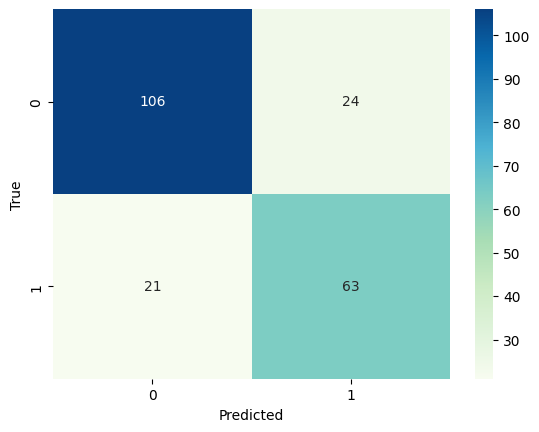

In [26]:
#Creo la matriz de confusión
tabla=confusion_matrix(y_test, y_pred)

#Grafico la matriz de confusión
sns.heatmap(tabla,cmap='GnBu',annot=True,fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')

In [27]:
#Calculo las métricas en el conjunto de evaluación
accuracy=accuracy_score(y_test,y_pred)
recall=recall_score(y_test,y_pred,)
f1=f1_score(y_test,y_pred,)

print("Accuracy: "+str(accuracy))
print("Recall: "+str(recall))
print("f1 score: "+str(f1))

Accuracy: 0.7897196261682243
Recall: 0.75
f1 score: 0.736842105263158


#### Graficamos el árbol

In [28]:
plt.figure(figsize=(100,100))

tree_plot_completo=tree.plot_tree(model,
                                 feature_names=ds_trabajo_x.columns.to_list(),
                                 filled=True,
                                 rounded=True,
                                 class_names=['Not Survived','Survived']) #model.classes_
plt.show(tree_plot_completo)

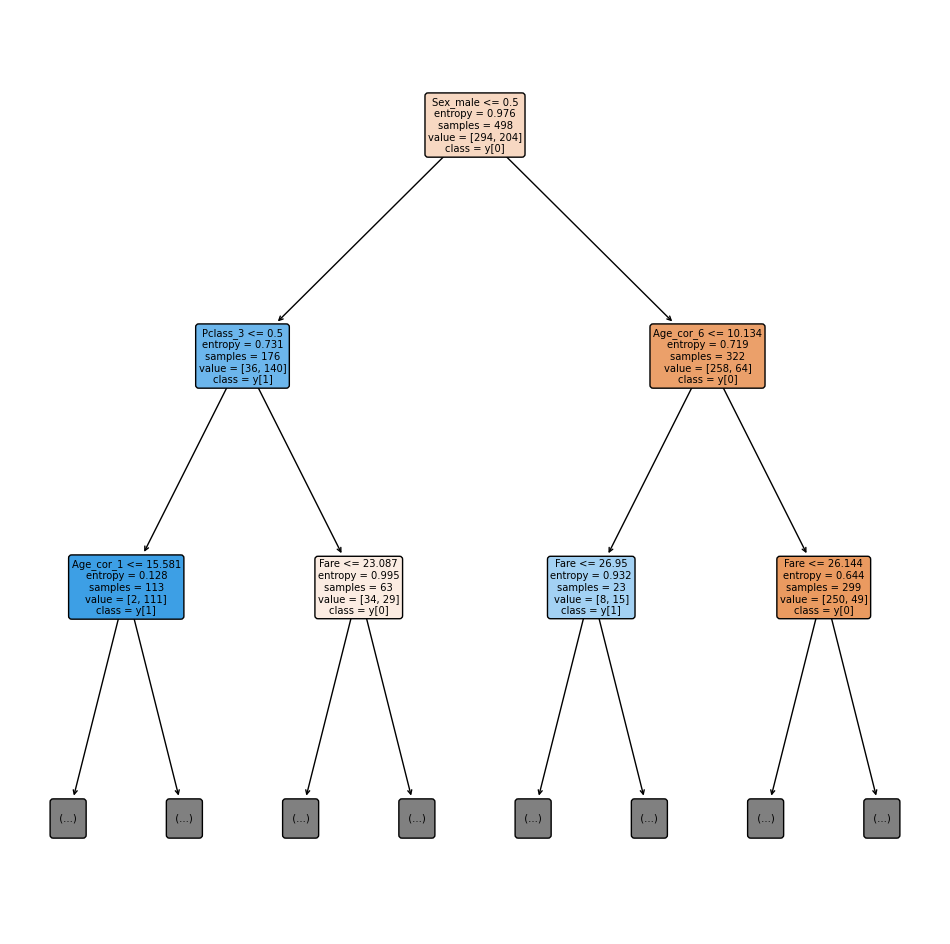

In [29]:
plt.figure(figsize=(12,12))

tree_plot=tree.plot_tree(model,
                         max_depth=2,
                         feature_names=ds_trabajo_x.columns.to_list(),
                         filled=True,
                         rounded=True,
                         class_names=True)

plt.show(tree_plot)

#### Importancia de atributos

La documentación dice:

feature importances : ndarray of shape (nfeatures,)<br>
The higher, the more important the feature. <br>
The importance of a feature is computed as the (normalized) total reduction of the criterion brought by that feature. <br>
It is also known as the Gini importance.<br>

feature importances : ndarray of shape (nfeatures,)<br>
Cuanto más alto, más importante es la característica.<br>
La importancia de una característica se calcula como la reducción total (normalizada) del criterio aportado por esa característica.<br>
También se conoce como la importancia de Gini.<br>

In [30]:
sorted(list(zip(ds_trabajo_x.columns.to_list(), model.feature_importances_)), key=lambda x: -x[1])

[('Sex_male', 0.44364080856136423),
 ('Pclass_3', 0.18122382620823338),
 ('Fare', 0.14185149395265056),
 ('Age_cor_6', 0.0627590200209882),
 ('Age_cor_5', 0.04389883946196923),
 ('Age_cor_7', 0.031232687415131303),
 ('Age_cor_10', 0.02724047594160441),
 ('Age_cor_9', 0.023732415835835702),
 ('Pclass_2', 0.023238178489838793),
 ('Age_cor_8', 0.015234421111044304),
 ('Age_cor_1', 0.00594783300133988),
 ('Age', 0.0),
 ('SibSp', 0.0),
 ('Parch', 0.0),
 ('Age_cor_2', 0.0),
 ('Age_cor_3', 0.0),
 ('Age_cor_4', 0.0),
 ('Embarked_Q', 0.0),
 ('Embarked_S', 0.0)]